In [1]:
library(Signac)
library(dittoSeq)
library(Seurat)
library(gridExtra)
library(GenomicRanges)
library(EnsDb.Hsapiens.v86)
library(BSgenome.Hsapiens.UCSC.hg38)
library(dplyr)
library(future)

plan("multicore", workers = 24)
options(future.globals.maxSize = 100000 * 1024^3)

set.seed(1234)

Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:gridExtra’:

    combine


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, s

In [2]:
sessionInfo()

R version 4.3.2 (2023-10-31)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.4 (Plow)

Matrix products: default
BLAS/LAPACK: /gpfs/home3/cruiz2/miniconda3/envs/r_env_standr/lib/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Amsterdam
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] future_1.33.1                     dplyr_1.1.4                      
 [3] BSgenome.Hsapiens.UCSC.hg38_1.4.5 BSgenome_1.70.2                  
 [5] rtracklayer_1.62.0         

## Create Seurat object from sampled h5ad 
Run only once!

In [4]:
library(reticulate)
use_condaenv("multi_integration")


Attaching package: 'reticulate'


The following object is masked from 'package:rtracklayer':

    import


The following object is masked from 'package:BiocIO':

    import




In [5]:
sceasy::convertFormat('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/Mannens2024/Pool_peaks_multiome.h5ad', 
                      from="anndata", to="seurat", assay='ATAC',
                       outFile='/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/Mannens2024/Pool_peaks_multiome.rds')

X -> counts

Warning message:
"Key 'UMAP_' taken, using 'umap_' instead"


An object of class Seurat 
410863 features across 166785 samples within 1 assay 
Active assay: ATAC (410863 features, 0 variable features)
 2 layers present: counts, data
 19 dimensional reductions calculated: Embedding, LSI, LSI_b, LSI_main, TSNE, TSNE_1, TSNE_10, TSNE_2, TSNE_3, TSNE_4, TSNE_5, TSNE_bin, TSNE_main, TSNE_old, UMAP, UMAP3D, UMAP3D_main, UMAP_main, umap

## Load and setup the 10x multiome object

In [3]:
# Mannens2024 ATAC

# set the path to the directory you want to list
path <- "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples"

# use list.dirs() function to list only directories
dir_list_mannens <- list.dirs(path, recursive = FALSE, full.names = TRUE)
dir_list_mannens

[1] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X232_1_AB_2"   
  [2] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X232_2_AB_2"   
  [3] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X232_3_AB_2"   
  [4] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X232_4_AB_2"   
  [5] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X242_1_AB_2"   
  [6] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X242_2_AB_2"   
  [7] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X242_3_ABC_1"  
  [8] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X242_4_AB_2"   
  [9] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X250_1_AB_2"   
 [10] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X250_2_AB_2"   
 [11] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X250_3_ABC_1"  
 [12] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X250_4_ABC_1"  
 [13] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X279_1_ABC_1"  
 [14] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X279_2_ABC_1"  
 [15] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X279_3_AB_3"   
 [16] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X280_1_ABCD_1" 
 [17] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X280_2_ABCD_1" 
 [18] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X280_3_ABCD_1" 
 [19] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X286_1_AB_3"   
 [20] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X286_2_AB_3"   
 [21] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X286_7_ABC_1"  
 [22] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X286_8_ABC_1"  
 [23] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X290_1_ABCD_1" 
 [24] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X290_2_ABCD_1" 
 [25] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X291_2_AB_3"   
 [26] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X291_3_AB_3"   
 [27] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X312_1_AB_2"   
 [28] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X312_2_AB_2"   
 [29] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X312_3_AB_2"   
 [30] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X312_4_AB_2"   
 [31] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X312_5_AB_2"   
 [32] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X312_6_AB_2"   
 [33] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X313_1_AB_2"   
 [34] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X313_2_AB_2"   
 [35] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X313_3_AB_2"   
 [36] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X313_4_AB_2"   
 [37] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X313_5_AB_2"   
 [38] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X313_6_ABC_1"  
 [39] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X315_1_AB_2"   
 [40] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X315_2_AB_2"   
 [41] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X315_3_AB_2"   
 [42] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X315_4_AB_2"   
 [43] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X315_5_AB_2"   
 [44] "/projects/0/einf2548/cruiz/dmg/public_d

In [4]:
meta <- as.data.frame(readxl::read_excel("/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/Extended_data_1_sample_data.xlsx"))
meta

New names:
• `` -> `...13`


Sample_ID,Source_ID,Age_PCW,Region,TYPE,TSS enrichment,Cells,Median fragments/cell,RNA median UMIs,RNA median genes,Chemistry,Source,...13
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
232_1,BRC2218,6.6,Cerebellum,ATAC,6.81,9703,18273,0,0,v1,Cambridge,Sample QC
232_2,BRC2218,6.6,Cerebellum,ATAC,7.15,8105,18137,0,0,v1,Cambridge,Passed
232_3,BRC2218,6.6,Midbrain,ATAC,6.54,5533,63478,0,0,v1,Cambridge,Failed
232_4,BRC2218,6.6,Midbrain,ATAC,6.72,4026,61412,0,0,v1,Cambridge,NA
242_1,BRC2230,9.1,Hindbrain,ATAC,5.61,10630,16382,0,0,v1,Cambridge,NA
242_2,BRC2230,9.1,Hindbrain,ATAC,5.36,10820,15840,0,0,v1,Cambridge,NA
242_3,BRC2230,9.1,Midbrain,ATAC,6.74,10344,18531,0,0,v1,Cambridge,NA
242_4,BRC2230,9.1,Midbrain,ATAC,8.87,11330,30865,0,0,v1,Cambridge,NA
250_1,BRC2237,7.4,Cerebellum,ATAC,6.96,9593,34736,0,0,v1.1,Cambridge,NA


In [5]:
meta$Sample_ID <- paste0('10X',meta$Sample_ID)

samples <- meta %>% filter(TYPE=='MULTI') %>% pull(Sample_ID)
samples

[1] "10X280_1" "10X280_2" "10X280_3" "10X290_1" "10X290_2" "10X346_1"
 [7] "10X346_2" "10X346_3" "10X346_4" "10X365_2" "10X365_4" "10X370_1"
[13] "10X370_2" "10X370_3" "10X370_4" "10X402_1" "10X406_1" "10X406_2"
[19] "10X406_3" "10X406_4" "10X406_5" "10X406_6" "10X406_7"

In [6]:
# Create a regular expression from the samples vector
pattern <- paste(samples, collapse = "|")

# Use grep to filter paths that contain any of the sample names
dir_list_mannens <- grep(pattern, dir_list_mannens, value = TRUE)
dir_list_mannens

[1] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X280_1_ABCD_1" 
 [2] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X280_2_ABCD_1" 
 [3] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X280_3_ABCD_1" 
 [4] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X290_1_ABCD_1" 
 [5] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X290_2_ABCD_1" 
 [6] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X346_1_ABCD_1" 
 [7] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X346_2_ABCD_2" 
 [8] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X346_3_ABCD_2" 
 [9] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X346_4_ABCD_2" 
[10] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X365_2_ABCDE_2"
[11] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X365_4_ABCDE_2"
[12] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X370_1_ABCD_2" 
[13] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X370_2_ABCD_2" 
[14] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X370_3_ABCDE_2"
[15] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X370_4_ABCD_2" 
[16] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X402_1_ABCD_1" 
[17] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X406_1_ABCD_2" 
[18] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X406_2_ABCD_2" 
[19] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X406_3_ABCD_2" 
[20] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X406_4_ABCD_2" 
[21] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X406_5_ABCD_2" 
[22] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X406_6_ABCD_2" 
[23] "/projects/0/einf2548/cruiz/dmg/public_data/Mannens2024/10X_samples/10X406_7_ABCD_2"

In [7]:
# Assuming dir_list_mannens contains the list of directories
dir_names_mannens <- sapply(dir_list_mannens, function(x) {
  # Extract the last part of the path (the directory name)
  dir_name <- tail(strsplit(x, "/")[[1]], n = 1)
  
  # Split the directory name by underscore and keep the first two parts
  sample_name <- paste(strsplit(dir_name, "_")[[1]][1:2], collapse = "_")
  
  return(sample_name)
})

names(dir_names_mannens) <- NULL
# Print the resulting sample names
dir_names_mannens

[1] "10X280_1" "10X280_2" "10X280_3" "10X290_1" "10X290_2" "10X346_1"
 [7] "10X346_2" "10X346_3" "10X346_4" "10X365_2" "10X365_4" "10X370_1"
[13] "10X370_2" "10X370_3" "10X370_4" "10X402_1" "10X406_1" "10X406_2"
[19] "10X406_3" "10X406_4" "10X406_5" "10X406_6" "10X406_7"

In [8]:
atac_multiome <- readRDS('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/Mannens2024/Pool_peaks_multiome.rds')
cells <- paste0(colnames(atac_multiome), '-1')
head(cells)

[1] "10X280_1:ACGCCACAGGTAACGA-1" "10X280_1:CAGGAAGGTTAACGAT-1"
[3] "10X406_1:TACGTACAGTGACCTG-1" "10X280_1:ATTGGTTCATTGACAT-1"
[5] "10X280_1:ATTGGCTAGTACTGGT-1" "10X280_1:CAGATTCAGCAGCTCA-1"

In [9]:
rna_multiome <- list()
for (i in 1:length(dir_list_mannens)) {
    seu_obj.data <- Read10X_h5(paste0(dir_list_mannens[i], '/raw_feature_bc_matrix.h5'))
    
    # Check if seu_obj.data has different modalities
    if (is.list(seu_obj.data) && "Gene Expression" %in% names(seu_obj.data)) {
        seu_obj.data <- seu_obj.data[["Gene Expression"]]
    }
    
    seu_obj <- CreateSeuratObject(seu_obj.data, min.features = 0, min.cells = 0,
                                  project = dir_names_mannens[i])
    seu_obj <-  RenameCells(object = seu_obj, new.names = paste0(dir_names_mannens[i], ':', colnames(seu_obj)))
    seu_obj <- subset(seu_obj, 
                      cells = cells
                     )
    cat(' ############################################\n',
      '### Cells in sample ', dir_names_mannens[i], 'are ', ncol(seu_obj), '###\n',
      '############################################\n')
    
    rna_multiome <- append(rna_multiome, seu_obj)
}

Genome matrix has multiple modalities, returning a list of matrices for this genome

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


 ############################################
 ### Cells in sample  10X280_1 are  9181 ###
 ############################################


Genome matrix has multiple modalities, returning a list of matrices for this genome

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


 ############################################
 ### Cells in sample  10X280_2 are  8737 ###
 ############################################


Genome matrix has multiple modalities, returning a list of matrices for this genome

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


...

 ############################################
 ### Cells in sample  10X406_5 are  6453 ###
 ############################################


Genome matrix has multiple modalities, returning a list of matrices for this genome

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


 ############################################
 ### Cells in sample  10X406_6 are  5029 ###
 ############################################


Genome matrix has multiple modalities, returning a list of matrices for this genome

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


 ############################################
 ### Cells in sample  10X406_7 are  3246 ###
 ############################################


In [10]:
rna_multiome_merged <- merge(rna_multiome[[1]], y = unlist(rna_multiome[2:length(rna_multiome)]))
rna_multiome_merged

An object of class Seurat 
59483 features across 166785 samples within 1 assay 
Active assay: RNA (59483 features, 0 variable features)
 23 layers present: counts.10X280_1, counts.10X280_2, counts.10X280_3, counts.10X290_1, counts.10X290_2, counts.10X346_1, counts.10X346_2, counts.10X346_3, counts.10X346_4, counts.10X365_2, counts.10X365_4, counts.10X370_1, counts.10X370_2, counts.10X370_3, counts.10X370_4, counts.10X402_1, counts.10X406_1, counts.10X406_2, counts.10X406_3, counts.10X406_4, counts.10X406_5, counts.10X406_6, counts.10X406_7

In [11]:
dmg <- readRDS('/projects/0/einf2548/cruiz/dmg/data/rna_dmg_atlas_scglue_embbeding.rds')
dmg

An object of class Seurat 
19248 features across 397794 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [12]:
rna_multiome_merged <- subset(rna_multiome_merged, features=rownames(dmg))
rna_multiome_merged

An object of class Seurat 
18813 features across 166785 samples within 1 assay 
Active assay: RNA (18813 features, 0 variable features)
 23 layers present: counts.10X280_1, counts.10X280_2, counts.10X280_3, counts.10X290_1, counts.10X290_2, counts.10X346_1, counts.10X346_2, counts.10X346_3, counts.10X346_4, counts.10X365_2, counts.10X365_4, counts.10X370_1, counts.10X370_2, counts.10X370_3, counts.10X370_4, counts.10X402_1, counts.10X406_1, counts.10X406_2, counts.10X406_3, counts.10X406_4, counts.10X406_5, counts.10X406_6, counts.10X406_7

In [13]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,16286845,869.9,29030362,1550.4,29030362,1550.4
Vcells,10484557033,79990.9,15033155950,114693.9,12049663376,91931.7


In [14]:
atac_multiome

An object of class Seurat 
410863 features across 166785 samples within 1 assay 
Active assay: ATAC (410863 features, 0 variable features)
 2 layers present: counts, data
 19 dimensional reductions calculated: Embedding, LSI, LSI_b, LSI_main, TSNE, TSNE_1, TSNE_10, TSNE_2, TSNE_3, TSNE_4, TSNE_5, TSNE_bin, TSNE_main, TSNE_old, UMAP, UMAP3D, UMAP3D_main, UMAP_main, umap

In [15]:
rna_multiome_merged <- JoinLayers(rna_multiome_merged)
rna_multiome_merged

An object of class Seurat 
18813 features across 166785 samples within 1 assay 
Active assay: RNA (18813 features, 0 variable features)
 1 layer present: counts

In [16]:
rna_counts <- GetAssayData(rna_multiome_merged, slot='counts')
atac_counts <- GetAssayData(atac_multiome, slot='counts')

Warning message:
"The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead."


In [25]:
colnames(atac_counts) <- paste0(colnames(atac_counts), '-1')

# Extract the column names from atac_counts
atac_columns <- colnames(atac_counts)

# Reorder the columns of rna_counts based on atac_counts
rna_counts_reordered <- rna_counts[, atac_columns]

# Verify that the column names match
all.equal(colnames(rna_counts_reordered), colnames(atac_counts))

[1] TRUE

In [27]:
# Create Seurat object
obj.multi <- CreateSeuratObject(counts = rna_counts_reordered)

In [29]:
# add the ATAC-seq assay
grange.counts <- StringToGRanges(rownames(atac_counts), sep = c(":", "-"))
grange.use <- seqnames(grange.counts) %in% standardChromosomes(grange.counts)
atac_counts <- atac_counts[as.vector(grange.use), ]
# Get gene annotations
annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)
# Change style to UCSC
seqlevelsStyle(annotations) <- 'UCSC'
genome(annotations) <- "hg38"

# Add in ATAC-seq data as ChromatinAssay object
chrom_assay <- CreateChromatinAssay(
  counts = atac_counts,
  sep = c(":", "-"),
  genome = 'hg38',
  # fragments = frag.file,
  # min.cells = 10,
  annotation = annotations
)

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

In [30]:
# Add the ATAC assay to the multiome object
obj.multi[["ATAC"]] <- chrom_assay

In [31]:
saveRDS(obj.multi, 'mannens_multiome.rds')

## Create H5ad RNA for SCENIC+
Run only once!

In [3]:
library(reticulate)
use_condaenv("multi_integration")


Attaching package: 'reticulate'


The following object is masked from 'package:rtracklayer':

    import


The following object is masked from 'package:BiocIO':

    import




In [4]:
multiome <- readRDS('mannens_multiome.rds')

multiome[["RNA"]] <- as(object = multiome[["RNA"]], Class = "Assay")
multiome

Warning message:
"No layers found matching search pattern provided"
Warning message:
"No layers found matching search pattern provided"
Warning message:
"No layers found matching search pattern provided"
Warning message:
"Layer 'data' is empty"
Warning message:
"No layers found matching search pattern provided"
Warning message:
"No layers found matching search pattern provided"
Warning message:
"Layer 'scale.data' is empty"
Warning message:
"Assay RNA changing from Assay5 to Assay"


An object of class Seurat 
429676 features across 166785 samples within 2 assays 
Active assay: RNA (18813 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: ATAC

In [5]:
sceasy::convertFormat(multiome, 
                      from="seurat", to="anndata", assay='RNA',
                       outFile='mannens_multiome.h5ad')

AnnData object with n_obs × n_vars = 166785 × 18813
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC'
    var: 'name'

## Load and setup the 10x scATAC-seq query

In [3]:
obj.atac <- readRDS('dmg_atac.rds')

## Load and setup the rna Ref

In [4]:
obj.rna <- readRDS('/projects/0/einf2548/cruiz/dmg/data/references/Braun2023/subset_fetal_brain_atlas_all_genes.rds')
obj.rna

An object of class Seurat 
18675 features across 499781 samples within 1 assay 
Active assay: RNA (18675 features, 0 variable features)
 2 layers present: counts, data
 1 dimensional reduction calculated: umap

In [5]:
table(obj.rna$PrevClusters)


   0   10   11   12   13   14   15   16   17   19   20   21   22   23   24   25 
 741  729 3701 2827 1748 1093 1833 2497  502 1499 1867  518  521 1315  799  499 
  26   27   28   29   31   32   33   34   35   36   37   38   39   40   41   42 
  42  201  793  682 1520  556 1270  665  768 1062  950 1494  658 1065    3   38 
  43   44   45   46   47   48   49   50   51   52   53   54   55   56   57   58 
  35   50   48   20   36    8   31  276  483  139 1134  672 1059  450  365  393 
  59   60   61   62   63   64   65   66   67   68   69   70   71   72   74   75 
1244  332  528  522  279 1129  332  504  722  451  637  368  233  482  799 1923 
  76   77   78   79   80   81   83   85   87   88   89   90   91   92   93   94 
2093  713  545 2273 1292  637  521  496  690  431  603  736  371  329  915  308 
  95   96   97   98   99  100  101  102  103  105  106  107  108  109  110  111 
 412  920 1715  369  207 1714 1353 1665  890  598 1197  600   59   84  281  365 
 112  113  114  115  116  1

In [6]:
detailed_meta <- as.data.frame(data.table::fread('/projects/0/einf2548/cruiz/dmg/data/references/Braun2023/detailed_annotation_Mossi.csv')) %>% rename('PrevClusters'='PrevCluster')
detailed_meta

V1,ClusterID,CellClass,AnnotationName,AnnotationDescription,AnnotationDefinition,PrevClusters,batch
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>
0-0,0,Glioblast,RGL,Radial glia (RGL; +HES1),+HES1,507,0
1-0,1,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,506,0
2-0,2,Pre-astrocyte,PREAC,Pre-astrocyte (PREAC; +BCAN +TNC +AQP4),+BCAN +TNC +AQP4,515,0
3-0,3,Pre-astrocyte,P-TEL,Embryonic telencephalon (P-TEL; +FOXG1),+FOXG1,516,0
4-0,4,Glioblast,GBL,Glioblast (GBL; +BCAN +TNC),+BCAN +TNC,517,0
5-0,5,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,518,0
6-0,6,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,513,0
7-0,7,Pre-astrocyte,O-HEM,Cortical Hem (O-HEM; +CRYAB +RSPO2),+CRYAB +RSPO2,512,0
8-0,8,Pre-astrocyte,GBL,Glioblast (GBL; +BCAN +TNC),+BCAN +TNC,467,0


In [7]:
meta <- obj.rna@meta.data %>%
  left_join(detailed_meta, by = "PrevClusters")
meta

barcode,CellClass.x,CellCycle,Clusters,Donor,MitoFraction,NGenes,PrevClusters,SampleID,Sex,⋯,TotalUMIs,Age,Region,V1,ClusterID,CellClass.y,AnnotationName,AnnotationDescription,AnnotationDefinition,batch
<chr>,<fct>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,⋯,<dbl>,<dbl>,<fct>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>
10X156_5:CTCATTAAGCGTGTCC,Radial glia,0.0020885547,127,XDD:334,0.004177109,2419,561,10X156_5,,⋯,4788,8.0,Midbrain,102-1,102,Radial glia,S-CC,Cell cycle (S-CC; +TOP2A),+TOP2A,1
10X254_5:GCCAGCAGTGGCTTGC,Glioblast,0.0094677582,18,XDD:385,0.064355172,3698,506,10X254_5,,⋯,7816,14.0,Diencephalon,1-0,1,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,0
10X112_1:CAAGTTGCAACACCCG,Neuronal IPC,0.0125599448,69,XHU:305,0.014386847,1919,11,10X112_1,,⋯,4379,7.5,Forebrain,21-3,21,Neuronal IPC,NBL,Neuroblast (NBL; +NHLH1),+NHLH1,3
10X288_1:CGCAGGTAGTGGCGAT,Neuron,0.0011734189,406,XDD:395,0.019948123,5114,150,10X288_1,,⋯,16192,6.0,Brain,71-4,71,Neuron,NT-VGLUT2,Glutamatergic 2 (NT-VGLUT2; +SLC17A6),+SLC17A6,4
10X288_6:GTGTGATGTTAGTCGT,Radial glia,0.0088906502,124,XDD:395,0.027974404,5882,564,10X288_6,,⋯,17659,6.0,Brain,99-1,99,Radial glia,RGL,Radial glia (RGL; +HES1),+HES1,1
10X188_3:TGTTTGTAGATTGGGC,Radial glia,0.0408066995,177,XDD:351,0.028541101,3709,390,10X188_3,,⋯,8479,12.0,Telencephalon,6-1,6,Radial glia,S-G2M,Cell cycle G2/M phase (S-G2M; +TOP2A +PLK1),+TOP2A +PLK1,1
10X102_2:AGCGTCGGTTAAAGAC,Neuroblast,0.0013852548,296,XHU:297,0.012929044,2540,356,10X102_2,,⋯,6497,10.0,Telencephalon,9-2,9,Neuroblast,P-TEL,Embryonic telencephalon (P-TEL; +FOXG1),+FOXG1,2
10X112_2:CAGATCAAGCTCCTCT,Radial glia,0.0050801095,165,XHU:305,0.011918718,2456,372,10X112_2,,⋯,5118,7.5,Forebrain,16-1,16,Radial glia,P-TEL,Embryonic telencephalon (P-TEL; +FOXG1),+FOXG1,1
10X99_5:CAGCTAAGTCCATGAT,Neuron,0.0010366275,585,BRC2021,0.004837595,1584,20,10X99_5,,⋯,2894,8.0,Diencephalon,78-4,78,Neuron,NEUR,Neuron (NEUR; +INA),+INA,4


In [8]:
obj.rna$DetailedCellClass <- meta$CellClass.y

In [9]:
obj.rna$DetailedCellClass <- recode(obj.rna$DetailedCellClass,
                                     'Failed'='COP')

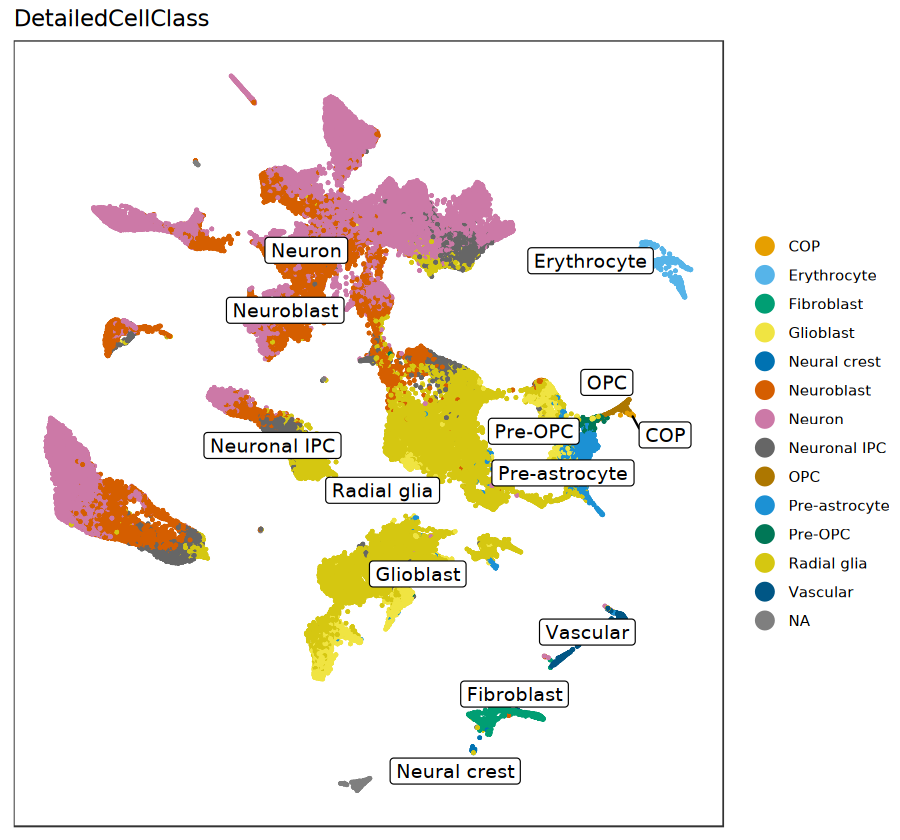

In [10]:
options(repr.plot.height = 7, repr.plot.width = 7.5)
dittoDimPlot(subset(obj.rna, cells = sample(Cells(obj.rna), 100000)),
             reduction.use = "umap", var = "DetailedCellClass", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

In [11]:
table(obj.rna$DetailedCellClass)


          COP   Erythrocyte    Fibroblast     Glioblast  Neural crest 
          207          2677          5737         28094           264 
   Neuroblast        Neuron  Neuronal IPC           OPC Pre-astrocyte 
        85476        168852         33361          1637          9776 
      Pre-OPC   Radial glia      Vascular 
         1576        155937          3426 

In [12]:
obj.rna@meta.data <- obj.rna@meta.data %>%
  mutate(DetailedCellClass = ifelse(is.na(DetailedCellClass), 'NA', as.character(DetailedCellClass)))

In [13]:
obj.rna <- subset(obj.rna, DetailedCellClass == 'NA', invert = TRUE)
obj.rna

An object of class Seurat 
18675 features across 497020 samples within 1 assay 
Active assay: RNA (18675 features, 0 variable features)
 2 layers present: counts, data
 1 dimensional reduction calculated: umap

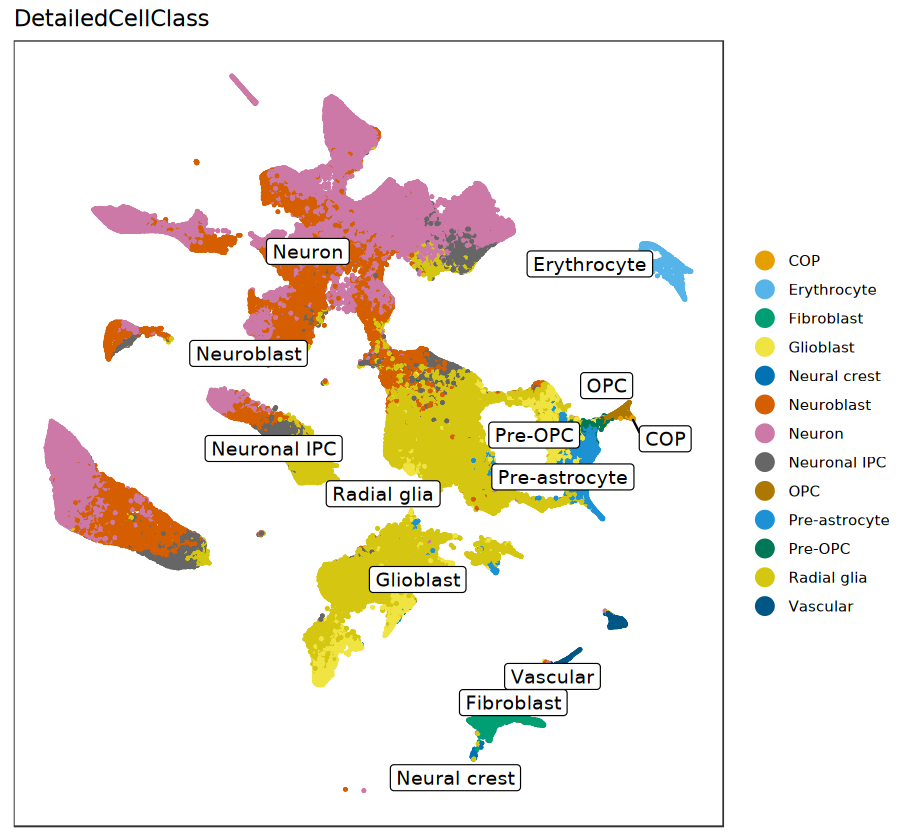

In [14]:
options(repr.plot.height = 7, repr.plot.width = 7.5)
dittoDimPlot(obj.rna,
             reduction.use = "umap", var = "DetailedCellClass", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

## Preprocessing/normalization for all datasets

In [15]:
obj.rna <- obj.rna %>% NormalizeData()%>%FindVariableFeatures()%>%ScaleData()%>%RunPCA()

Centering and scaling data matrix

PC_ 1 
Positive:  VIM, HMGB2, ZFP36L1, TOP2A, CENPF, CDK1, SMC4, CKS2, PTTG1, UBE2C 
	   MAD2L1, PBK, TPX2, MKI67, TTYH1, NUF2, BIRC5, CCNA2, ASPM, GTSE1 
	   DLGAP5, DIAPH3, MIS18BP1, NDC80, APOLD1, HES1, CENPE, ECT2, CCNB2, AURKB 
Negative:  STMN2, MYT1L, CTNNA2, INA, NRXN1, CNTNAP2, CCSER1, SYT1, ANK3, LRRC7 
	   GRIA2, FAM155A, RBFOX1, PTPRD, RUNX1T1, CELF4, HECW1, NRG1, DCC, ENOX1 
	   DSCAM, XKR4, GRIK2, SEMA6D, RALYL, AFF3, KCNB2, DOCK4, EPHA5, ATP8A2 
PC_ 2 
Positive:  UBE2C, TOP2A, CENPF, BIRC5, PTTG1, PBK, CDK1, CCNA2, HMGB2, GTSE1 
	   CDC20, MAD2L1, NUF2, TPX2, CCNB2, AURKB, DLGAP5, CKS2, CCNB1, MKI67 
	   ASPM, NUSAP1, PLK1, PIMREG, CDCA8, NDC80, KPNA2, CDCA3, UBE2T, SGO2 
Negative:  S100A11, ARHGAP29, FOXC1, COL3A1, IFITM3, COL4A1, IGFBP7, DLC1, IFITM2, COL6A2 
	   EVA1B, FN1, BGN, OLFML3, LAMA4, NID1, DCN, COL1A2, TFPI, APOE 
	   ETS1, ITIH5, COLEC12, ATP1A2, EDNRA, VAMP5, FOXF2, COBLL1, CAVIN3, CDC42EP5 
PC_ 3 
Positive:  MDK, ERBB4, C

In [16]:
obj.multi <- readRDS('mannens_multiome.rds')

In [17]:
# normalize multiome RNA
DefaultAssay(obj.multi) <- "RNA"
obj.multi <- obj.multi %>% NormalizeData()%>%FindVariableFeatures()%>%ScaleData()%>%RunPCA()
# normalize multiome ATAC
DefaultAssay(obj.multi) <- "ATAC"
obj.multi <- RunTFIDF(obj.multi)
obj.multi <- FindTopFeatures(obj.multi, min.cutoff = "q0")
# Query was already normalized - see signac_dmg_atlas.ipynb

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  DCC, GRIK2, ROBO1, LRRC7, NRXN3, NRG1, ERBB4, STMN2, CNTNAP2, THSD7A 
	   RIMS2, ATRNL1, CNTN4, NEGR1, EPHA5, EBF3, TENM3, LHX1, XKR4, KHDRBS2 
	   DPP10, CACNA2D1, ZNF385D, FSTL5, ZNF804A, UCHL1, FOXP2, UNC5C, GAD1, CSMD1 
Negative:  FLT1, ADGRF5, EPAS1, PRKCH, ETS1, SLC7A5, COBLL1, CGNL1, ADGRL4, PECAM1 
	   DIPK2B, KDR, ERG, RASGRP3, ENG, SLC38A5, PTPRB, EGFL7, PDGFB, IGFBP7 
	   ESAM, ARHGAP29, CD34, CDH5, FLI1, MYCT1, FOXQ1, CD93, TIE1, AFAP1L1 
PC_ 2 
Positive:  DOCK8, ADAM28, SAMSN1, APBB1IP, FYB1, SYK, C3, ATP8B4, CSF1R, MERTK 
	   IKZF1, RUNX1, CD83, CX3CR1, P2RY12, RBM47, OLR1, NPL, SLC9A9, TBXAS1 
	   SPP1, CYBB, MAF, DOCK2, PTPRC, AOAH, P2RY13, CPVL, LY86, RGS1 
Negative:  CDH2, SPTBN1, PTPRM, TUSC3, PDE10A, APBB2, EBF1, NREP, ARHGEF12, SESTD1 
	   GALNT18, CDH11, COBLL1, MYO1B, ABLIM1, PRKG1, RBMS3, BBS9, ARHGAP29, INSR 
	   ADGRL2, MAST4, CALD1, ROBO

## Map scATAC-seq dataset using bridge integration

In [ ]:
dims.atac <- 2:50
dims.rna <- 1:50
DefaultAssay(obj.multi) <-  "RNA"
DefaultAssay(obj.rna) <- "RNA"
obj.rna.ext <- PrepareBridgeReference(
  reference = obj.rna, bridge = obj.multi,
  reference.reduction = "pca", reference.dims = dims.rna,
  normalization.method = "LogNormalize")

Warning message:
"2 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 1998 features."
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 99950 anchors

Finding integration vectors

Finding integration vector weights

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Warning message:
"Layer counts isn't present in the assay object; returning NULL"

Integrating dataset 2 with reference dataset

Finding integration vectors

Integrating data

Computing nearest neighbor graph

Computing SNN

Generating normalized laplacian graph

Performing eigendecomposition of the normalized laplacian graph

Warning message in PrepDR(object = object, features = features, slot = "data", verbose = verbose):
"The following 5742 features requested have zero variance (running reduction without them): chr10-27319742-27320142, chr10-27344926-27345326, chr10-27345520-27345920, chr10-27347465-27

In [ ]:
bridge.anchor <- FindBridgeTransferAnchors(
  extended.reference = obj.rna.ext, query = obj.atac,
  reduction = "lsiproject", dims = dims.atac)